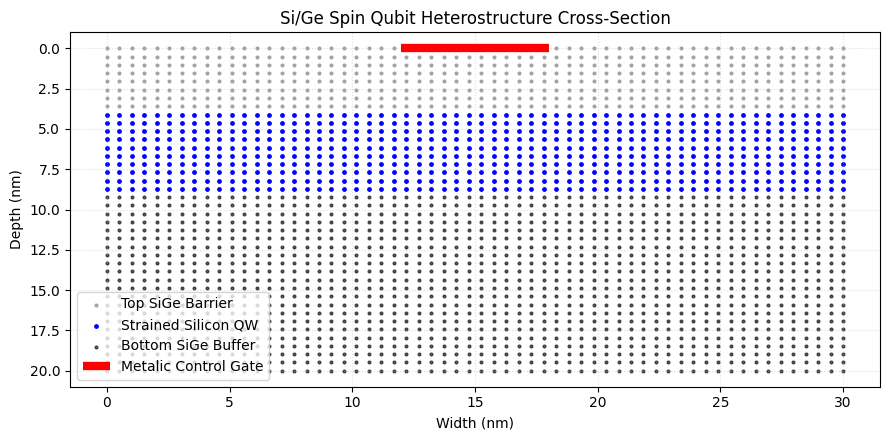

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
# 1. Setup the 2D grid dimensions (Width vs Depth in nanometers)
X, Y = np.meshgrid(np.linspace(0, 30, 60), np.linspace(0, 20, 40))

# 2. Divide the grid into the 3 typical layers of a Si/Ge qubit chip
is_top_sige   = Y < 4                # 0 to 4 nm deep
is_si_qw      = (Y >= 4) & (Y < 9)   # 4 to 9 nm deep (Where qubits live)
is_bottom_sige = Y >= 9               # 9 nm and deeper

# 3. Plot the layers
fig, ax = plt.subplots(figsize=(9, 4.5))
ax.scatter(X[is_top_sige], Y[is_top_sige], s=4, color='gray', alpha=0.6, label='Top SiGe Barrier')
ax.scatter(X[is_si_qw], Y[is_si_qw], s=6, color='blue', label='Strained Silicon QW')
ax.scatter(X[is_bottom_sige], Y[is_bottom_sige], s=4, color='k', alpha=0.6, label='Bottom SiGe Buffer')

# 4. Draw a metallic control gate on top (centered at 15nm, 6nm wide)
ax.plot([12, 18], [0, 0], color='red', lw=6, solid_capstyle='butt', label='Metalic Control Gate')

# 5. Format the plot (Inverting Y-axis so depth goes downwards)
ax.set_title("Si/Ge Spin Qubit Heterostructure Cross-Section")
ax.set_xlabel("Width (nm)")
ax.set_ylabel("Depth (nm)")
ax.invert_yaxis()
ax.legend(loc='lower left')
ax.grid(True, linestyle=':', alpha=0.4)
plt.tight_layout()
plt.savefig('C:/Users/mdram/Computational_Projects/semiconductor strain fields using FEM/plots/cross-section.png')
plt.show()

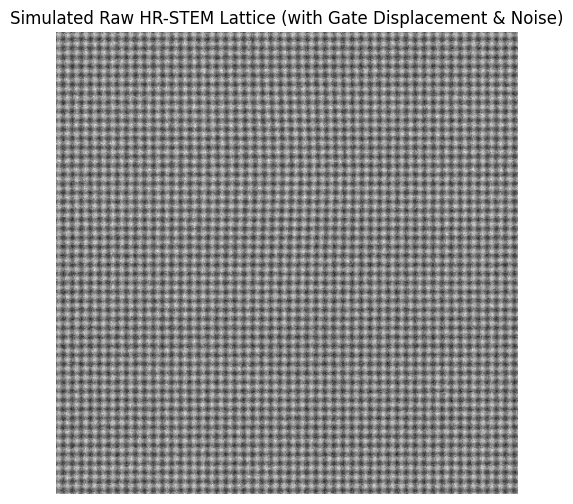

In [29]:
# 1. Define image parameters
img_size = 512
x = np.arange(img_size)
y = np.arange(img_size)
X, Y = np.meshgrid(x, y)

# 2. Define standard spatial frequencies for a perfect crystal lattice base
g_x = 0.1  # Base periodicity along X
g_y = 0.1  # Base periodicity along Y

# 3. Create a localized displacement field (u_x) to simulate strain under a gate
# We simulate a gate in the center (X around 256) causing a localized shift
center = img_size / 2
sigma = 60
# Displacement u_x is a localized sigmoid/gaussian shift mimicking gate tension
u_x = 3.0 * np.exp(-((X - center)**2 + (Y - 150)**2) / (2 * sigma**2))
u_y = np.zeros_like(Y) # Assume no vertical displacement for this initial test

# 4. Generate the simulated high-resolution atomic lattice image with displacement
# Real lattice intensity can be modeled as a sum of plane waves
strained_lattice = np.sin(2 * np.pi * g_x * (X - u_x)) + np.sin(2 * np.pi * g_y * (Y - u_y))

# 5. Add random Gaussian noise to simulate microscope detector limitations
noise = np.random.normal(0, 0.5, strained_lattice.shape)
experimental_sim = strained_lattice + noise

# Plot the simulated raw HR-STEM image
plt.figure(figsize=(6, 6))
plt.imshow(experimental_sim, cmap='gray')
plt.title("Simulated Raw HR-STEM Lattice (with Gate Displacement & Noise)")
plt.savefig('C:/Users/mdram/Computational_Projects/semiconductor strain fields using FEM/plots/cross-section_dis&noise.png')
plt.axis('off')
plt.show()

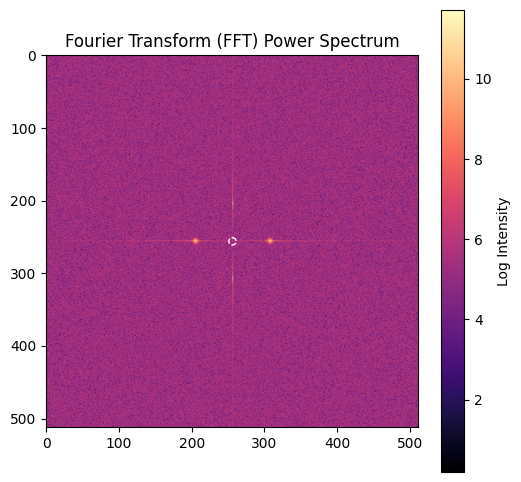

In [28]:
# 1. Compute 2D Fast Fourier Transform and shift the zero-frequency component to the center
fft_image = np.fft.fftshift(np.fft.fft2(experimental_sim))
magnitude_spectrum = np.log(1 + np.abs(fft_image))

# 2. Plot the Fourier Spectrum to identify Bragg reflections
plt.figure(figsize=(6, 6))
plt.imshow(magnitude_spectrum, cmap='magma')
plt.title("Fourier Transform (FFT) Power Spectrum")
plt.colorbar(label="Log Intensity")
plt.axcircle = plt.Circle((img_size/2, img_size/2), 5, color='white', fill=False, linestyle='--')
plt.gca().add_patch(plt.axcircle)
plt.axis('on') # Keep axes visible to identify peak coordinate pixels
plt.savefig('C:/Users/mdram/Computational_Projects/semiconductor strain fields using FEM/plots/cross-section_fft.png')

plt.show()

Isolating Bragg Peak 'g' at pixel coordinates: (307, 256)


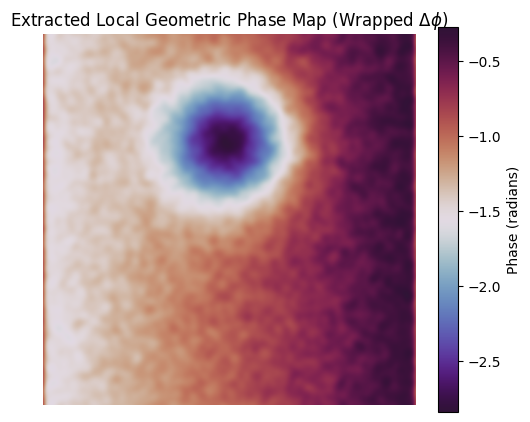

In [30]:
# 1. Identify the pixel coordinates of one primary Bragg peak along the X-direction
# In our clean synthetic setup, with g_x = 0.1, the peak sits roughly 51 pixels away from center
center_idx = img_size // 2
peak_x = center_idx + int(g_x * img_size)
peak_y = center_idx

print(f"Isolating Bragg Peak 'g' at pixel coordinates: ({peak_x}, {peak_y})")

# 2. Create a 2D Gaussian Mask centered on the selected Bragg peak
mask_radius = 15
X_m, Y_m = np.meshgrid(np.arange(img_size), np.arange(img_size))
gaussian_mask = np.exp(-((X_m - peak_x)**2 + (Y_m - peak_y)**2) / (2 * mask_radius**2))

# 3. Apply the mask and shift the isolated peak to the center of Fourier space
masked_fft = fft_image * gaussian_mask
shifted_fft = np.roll(masked_fft, (center_idx - peak_y, center_idx - peak_x), axis=(0, 1))
# 4. Perform Inverse FFT to yield the complex structural image
complex_image = np.fft.ifft2(np.fft.ifftshift(shifted_fft))
# 5. Extract the geometric phase profile (wrapped between -pi and +pi)
phase_map = np.angle(complex_image)

plt.figure(figsize=(6, 5))
plt.imshow(phase_map, cmap='twilight_shifted')
plt.title("Extracted Local Geometric Phase Map (Wrapped $\Delta\phi$)")
plt.colorbar(label="Phase (radians)")
plt.axis('off')
plt.savefig('C:/Users/mdram/Computational_Projects/semiconductor strain fields using FEM/plots/cross-section_phase.png')

plt.show()

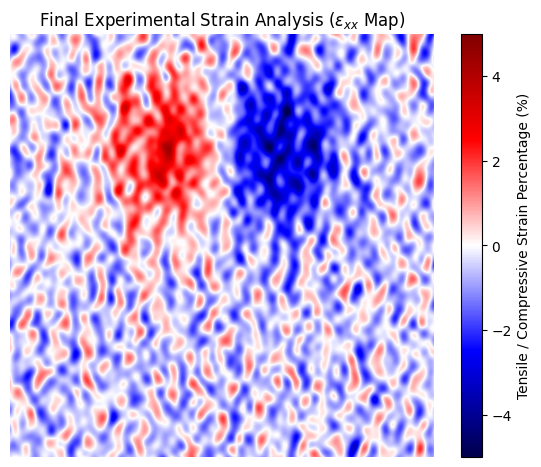

In [31]:
# 1. Phase unwrapping is required to remove artificial 2pi phase jumps
# For simplicity in this clean script, we use numpy's gradient on the phase field
# The strain is inversely proportional to the reference lattice vector magnitude
phase_gradient_x = np.gradient(phase_map, axis=1)

# 2. Compute the direct strain tensor component epsilon_xx
# Strain epsilon = -1 / (2 * pi * |g|) * d(phase)/dx
strain_xx = -1.0 / (2 * np.pi * g_x) * phase_gradient_x

# 3. Clean up edge artifacts introduced by Fourier boundaries
clean_strain_xx = strain_xx[20:-20, 20:-20]

# 4. Plot the final processed strain distribution map
plt.figure(figsize=(7, 5.5))
plt.imshow(clean_strain_xx * 100, cmap='seismic', vmin=-5, vmax=5)
plt.title("Final Experimental Strain Analysis ($\epsilon_{xx}$ Map)")
plt.colorbar(label="Tensile / Compressive Strain Percentage (%)")
plt.axis('off')
plt.savefig('C:/Users/mdram/Computational_Projects/semiconductor strain fields using FEM/plots/cross-section_strain.png')
plt.show()

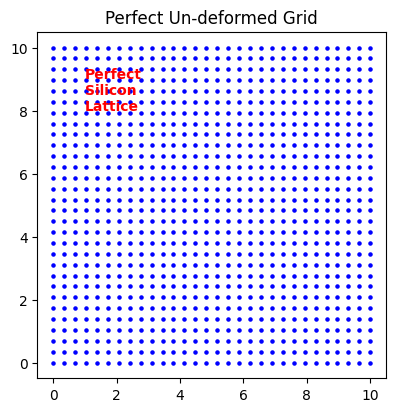

In [35]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a 30x30 clean grid
x = np.linspace(0, 10, 30)
y = np.linspace(0, 10, 30)
X, Y = np.meshgrid(x, y)

# 2. Plot the perfect grid
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(X, Y, s=5, color='blue')

# Label inside the plot
ax.text(1, 8, "Perfect\nSilicon\nLattice", color="red", fontsize=10, weight="bold")

ax.set_title("Perfect Un-deformed Grid")
plt.show()

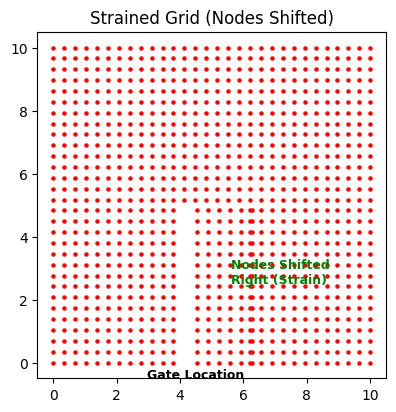

In [37]:
# 1. Copy the original coordinates
X_strained = X.copy()

# 2. Push the points near the center (X=5) slightly to the right (+0.4)
mask = (X > 4) & (X < 6) & (Y < 5)
X_strained[mask] += 0.4

# 3. Plot the strained grid
fig, ax = plt.subplots(figsize=(4.5, 4.5))
ax.scatter(X_strained, Y, s=5, color='red')

# Labels inside the plot
ax.text(4.5, -0.5, "Gate Location", color="black", fontsize=9, weight="bold", ha="center")
ax.text(5.6, 2.5, "Nodes Shifted\nRight (Strain)", color="g", fontsize=9, weight="bold")

ax.set_title("Strained Grid (Nodes Shifted)")
plt.show()

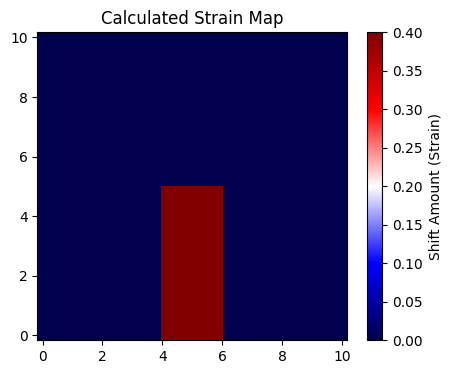

In [19]:
# 1. Calculate the difference (Displacement)
displacement_x = X_strained - X

# 2. Plot the color heatmap
plt.figure(figsize=(5, 4))
plt.pcolormesh(X, Y, displacement_x, cmap='seismic', shading='auto')
plt.colorbar(label="Shift Amount (Strain)")
plt.title("Calculated Strain Map")
plt.savefig('C:/Users/mdram/Computational_Projects/semiconductor strain fields using FEM/plots/cross-section1.png')
plt.show()

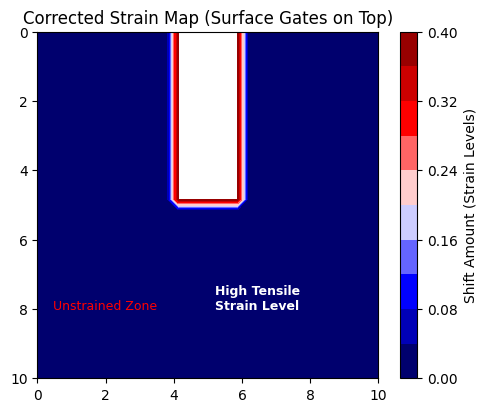

In [39]:
# Calculate the difference
displacement_x = X_strained - X

fig, ax = plt.subplots(figsize=(5.5, 4.5))
cp = ax.contourf(X, Y, displacement_x, levels=10, cmap='seismic')
plt.colorbar(cp, label="Shift Amount (Strain Levels)")

# FLIP THE Y-AXIS: Now 0 (Surface/Gate) is at the top, and 10 (Depth) is at the bottom!
ax.invert_yaxis()

# Adjust the label position to match the new top location
ax.text(5.2, 8, "High Tensile\nStrain Level", color="white", fontsize=9, weight="bold")
ax.text(2, 8, "Unstrained Zone", color="red", fontsize=9, ha="center")
ax.set_title("Corrected Strain Map (Surface Gates on Top)")
plt.savefig('C:/Users/mdram/Computational_Projects/semiconductor strain fields using FEM/plots/cross-section_gate.png')

plt.show()

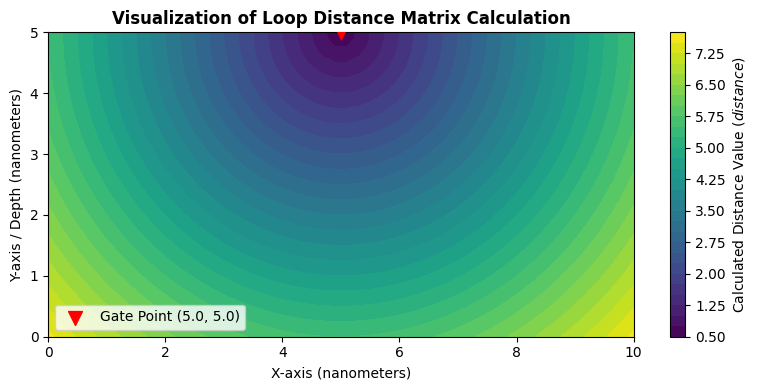

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a 2D Silicon Chip Grid (50x50 atoms/nodes)
grid_size = 50
X, Y = np.meshgrid(np.linspace(0, 10, grid_size), np.linspace(0, 5, grid_size))

# Initialize the distance array
distance_matrix = np.zeros_like(X)
gate_center = 5.0
# 2. Run your specific loop to calculate the distances
for i in range(grid_size):
    for j in range(grid_size):
        # Calculate distance from this pixel to the surface gate
        dx = X[i, j] - gate_center
        dy = 5.0 - Y[i, j]  # Distance down from the top surface
        distance = np.sqrt(dx**2 + dy**2) + 0.5  # +0.5 prevents dividing by zero
        
        # Store the distance value for plotting
        distance_matrix[i, j] = distance

# 3. Plot the distance field
fig, ax = plt.subplots(figsize=(8, 4))

# Using the 'viridis' colormap to show closeness (purple is closest, yellow is furthest)
contour = ax.contourf(X, Y, distance_matrix, cmap="viridis", levels=30)
cbar = fig.colorbar(contour, ax=ax)
cbar.set_label("Calculated Distance Value ($distance$)", fontsize=10)

# Mark the exact gate position at the top center
ax.scatter(gate_center, 5.0, color='red', marker='v', s=100, label='Gate Point (5.0, 5.0)', zorder=5)

ax.set_title("Visualization of Loop Distance Matrix Calculation", fontsize=12, fontweight='bold')
ax.set_xlabel("X-axis (nanometers)", fontsize=10)
ax.set_ylabel("Y-axis / Depth (nanometers)", fontsize=10)
ax.legend(loc='lower left')
plt.savefig('C:/Users/mdram/Computational_Projects/semiconductor strain fields using FEM/plots/')

plt.tight_layout()
plt.show()

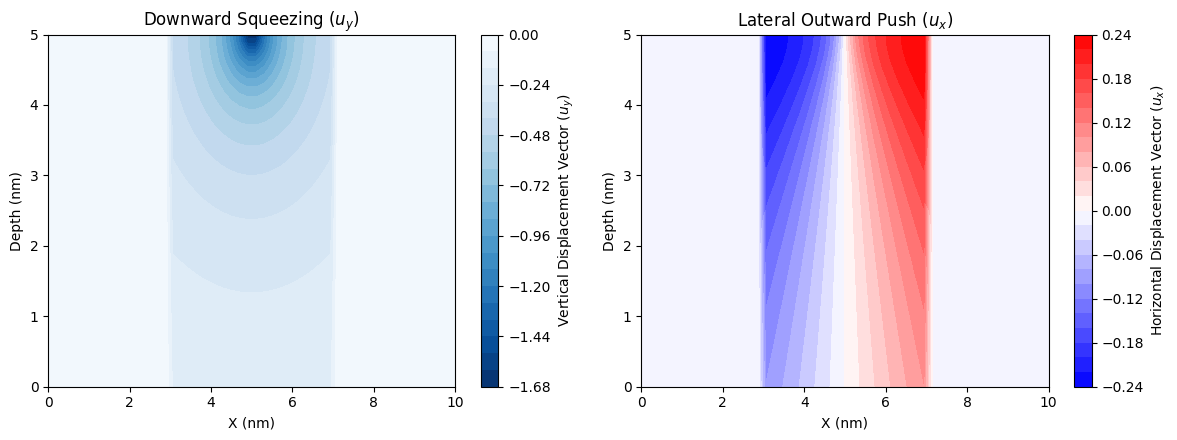

In [3]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Setup the 50x50 spatial layout
grid_size = 50
X, Y = np.meshgrid(np.linspace(0, 10, grid_size), np.linspace(0, 5, grid_size))

# Initialize arrays to zero
u_x = np.zeros_like(X)
u_y = np.zeros_like(Y)

gate_center = 5.0
gate_width = 2.0

# 2. Run only the requested elasticity physics logic
for i in range(grid_size):
    for j in range(grid_size):
        dx = X[i, j] - gate_center
        dy = 5.0 - Y[i, j]
        distance = np.sqrt(dx**2 + dy**2) + 0.5
        
        # Apply strict bounding box mask based on gate geometry
        if (gate_center - gate_width) < X[i, j] < (gate_center + gate_width):
            u_y[i, j] = -1.0 / distance        # Vertical compression
            u_x[i, j] = (dx / distance) * 0.3  # Lateral push

# 3. Plot both components side-by-side
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Plot Vertical Squeezing component
c1 = ax1.contourf(X, Y, u_y, cmap="Blues_r", levels=25)
fig.colorbar(c1, ax=ax1, label="Vertical Displacement Vector ($u_y$)")
ax1.set_title("Downward Squeezing ($u_y$)")
ax1.set_xlabel("X (nm)")
ax1.set_ylabel("Depth (nm)")

# Plot Horizontal Lateral Push component 
c2 = ax2.contourf(X, Y, u_x, cmap="bwr", levels=25)
fig.colorbar(c2, ax=ax2, label="Horizontal Displacement Vector ($u_x$)")
ax2.set_title("Lateral Outward Push ($u_x$)")
ax2.set_xlabel("X (nm)")
ax2.set_ylabel("Depth (nm)")
plt.savefig('C:/Users/mdram/Computational_Projects/semiconductor strain fields using FEM/plots/strain.png')
plt.tight_layout()
plt.show()

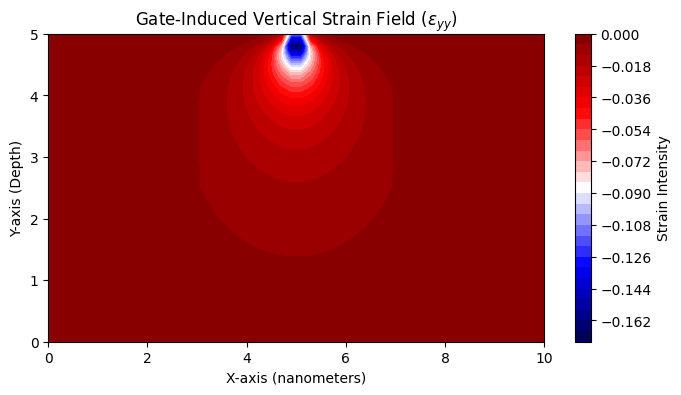

In [2]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a 2D Silicon Chip Grid (50x50 atoms/nodes)
grid_size = 50
X, Y = np.meshgrid(np.linspace(0, 10, grid_size), np.linspace(0, 5, grid_size))

# Initialize displacement arrays (how much each point moves)
u_x = np.zeros_like(X)
u_y = np.zeros_like(Y)

# 2. Simulate a Nano-Gate pressing down on the top surface
# We apply a force in the middle of the top edge (Y = 5)
gate_center = 5.0
gate_width = 2.0

for i in range(grid_size):
    for j in range(grid_size):
        # Calculate distance from this pixel to the surface gate
        dx = X[i, j] - gate_center
        dy = 5.0 - Y[i, j] # Distance down from the top surface
        distance = np.sqrt(dx**2 + dy**2) + 0.5 # +0.5 prevents dividing by zero
        
        # Simple elasticity physics: force fades out the deeper/further it goes
        if X[i, j] > (gate_center - gate_width) and X[i, j] < (gate_center + gate_width):
            u_y[i, j] = -1.0 / distance  # Squeezing down (-Y)
            u_x[i, j] = (dx / distance) * 0.3  # Pushing atoms out sideways (+/- X)

# 3. Calculate Strain Fields (The change in displacement)
# Strain is just the gradient (derivative) of how much things moved
strain_xx = np.gradient(u_x, axis=1) # Horizontal strain (stretching/squeezing)
strain_yy = np.gradient(u_y, axis=0) # Vertical strain

# 4. Plot the Vertical Strain Field
plt.figure(figsize=(8, 4))
# 'seismic' map makes compression blue, zero strain white, and tension red
plt.contourf(X, Y, strain_yy, cmap="seismic", levels=30)
plt.colorbar(label="Strain Intensity")
plt.title("Gate-Induced Vertical Strain Field ($\epsilon_{yy}$)")
plt.xlabel("X-axis (nanometers)")
plt.ylabel("Y-axis (Depth)")
fig.savefig(r'path\to\folder\image.png')
plt.show()

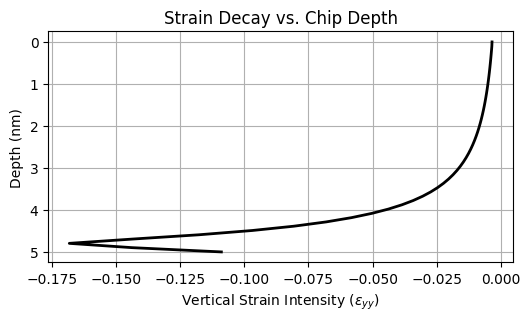

In [3]:
# Extract a vertical slice right down the middle of the gate (index 25)
middle_index = grid_size // 2
depth = Y[:, middle_index]
strain_at_center = strain_yy[:, middle_index]

plt.figure(figsize=(6, 3))
plt.plot(strain_at_center, depth, color="black", lw=2)
plt.gca().invert_yaxis() # Invert so top surface is at the top of the plot
plt.title("Strain Decay vs. Chip Depth")
plt.xlabel("Vertical Strain Intensity ($\epsilon_{yy}$)")
plt.ylabel("Depth (nm)")
plt.grid(True)
plt.show()

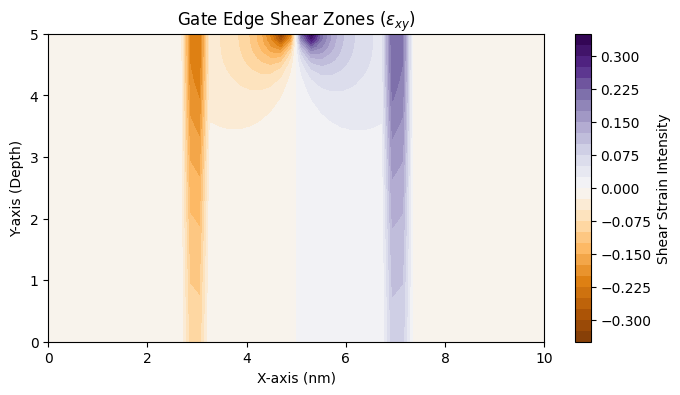

In [4]:
# Shear strain is the change of X-displacement as you go down Y, 
# plus the change of Y-displacement as you move across X.
strain_xy = np.gradient(u_x, axis=0) + np.gradient(u_y, axis=1)

plt.figure(figsize=(8, 4))
plt.contourf(X, Y, strain_xy, cmap="PuOr", levels=30) # Purple/Orange map works great for shear
plt.colorbar(label="Shear Strain Intensity")
plt.title("Gate Edge Shear Zones ($\epsilon_{xy}$)")
plt.xlabel("X-axis (nm)")
plt.ylabel("Y-axis (Depth)")
plt.show()

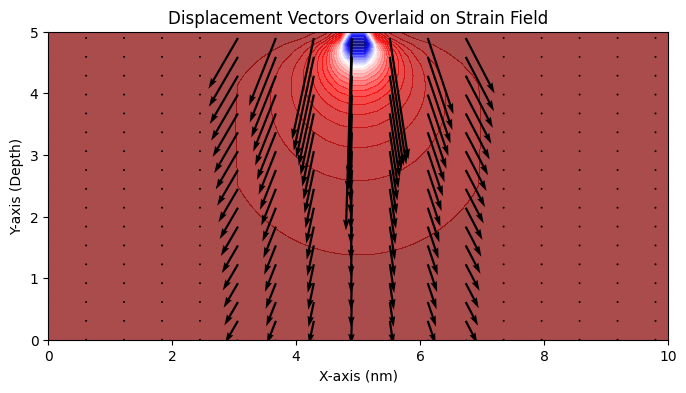

In [5]:
plt.figure(figsize=(8, 4))
# Plot the background strain map again
plt.contourf(X, Y, strain_yy, cmap="seismic", levels=30, alpha=0.7)

# Overlay arrows showing the displacement direction (skipping points so it's not crowded)
skip = (slice(None, None, 3), slice(None, None, 3))
plt.quiver(X[skip], Y[skip], u_x[skip], u_y[skip], color="black", scale=5)

plt.title("Displacement Vectors Overlaid on Strain Field")
plt.xlabel("X-axis (nm)")
plt.ylabel("Y-axis (Depth)")
plt.show()

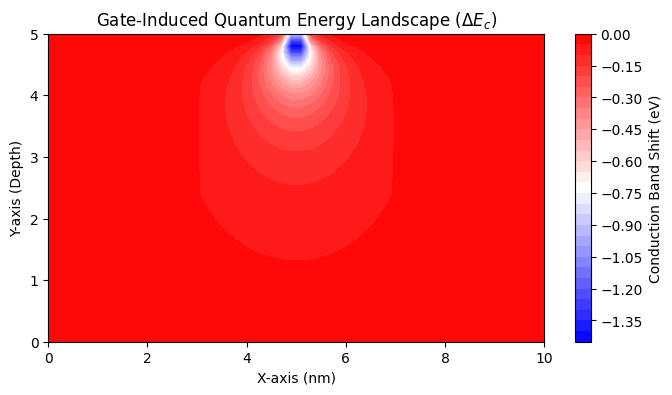

In [6]:
# Deformation potential for Silicon is roughly 8.6 electron-Volts (eV)
Xi = 8.6  

# Calculate the shifting energy landscapes for electrons across the chip
# Squeezing shifts the energy down, stretching shifts it up
energy_shift = Xi * strain_yy

plt.figure(figsize=(8, 4))
plt.contourf(X, Y, energy_shift, cmap="bwr", levels=30)
plt.colorbar(label="Conduction Band Shift (eV)")
plt.title("Gate-Induced Quantum Energy Landscape ($\Delta E_c$)")
plt.xlabel("X-axis (nm)")
plt.ylabel("Y-axis (Depth)")
plt.show()

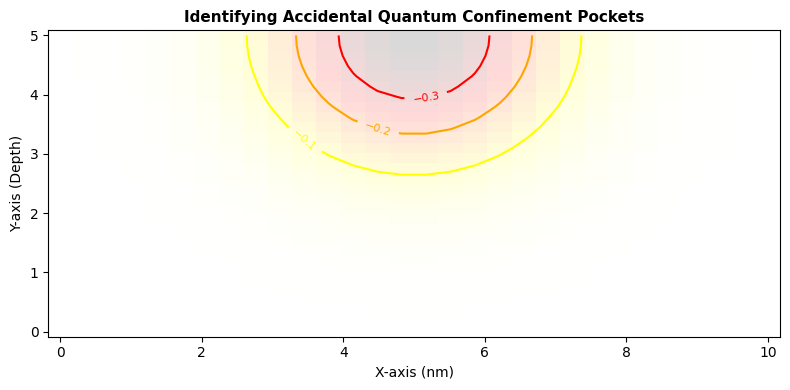

In [5]:


# 3. Plotting the 2D Slice
plt.figure(figsize=(8, 4))

# Plot the background color mesh using the sliced 2D arrays
plt.pcolormesh(X_slice, Y_slice, energy_slice, cmap="hot", shading="auto", alpha=0.15)

# Draw distinct contour lines ONLY where the energy drop is severe
cs = plt.contour(X_slice, Y_slice, energy_slice, levels=[-0.3, -0.2, -0.1], colors=["red", "orange", "yellow"])
plt.clabel(cs, inline=True, fontsize=8)

plt.title("Identifying Accidental Quantum Confinement Pockets", fontsize=11, fontweight='bold')
plt.xlabel("X-axis (nm)")
plt.ylabel("Y-axis (Depth)")
plt.tight_layout()
plt.show()

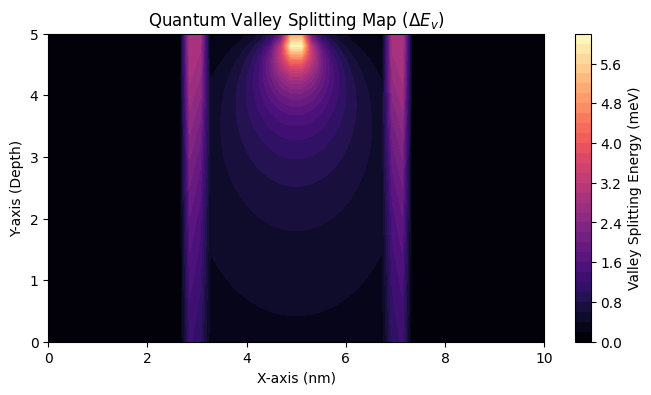

In [13]:
# 1. Define the valley coupling coefficient for Silicon (typically around 25 eV)
vo = 25.0  

# 2. Valley splitting is driven by the shear and asymmetry of the strain field
# We take the absolute difference between horizontal stretching and vertical squeezing
valley_splitting = vo * np.abs(strain_xx - strain_yy)

# 3. Plot the final Quantum Valley Map
plt.figure(figsize=(8, 4))
plt.contourf(X, Y, valley_splitting, cmap="magma", levels=30)
plt.colorbar(label="Valley Splitting Energy (meV)")

plt.title("Quantum Valley Splitting Map ($\Delta E_{v}$)")
plt.xlabel("X-axis (nm)")
plt.ylabel("Y-axis (Depth)")
plt.show()

In [18]:
#3d

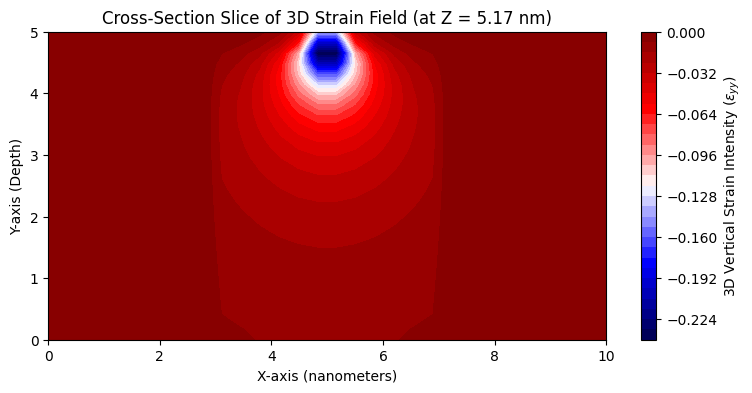

In [14]:
import numpy as np
import matplotlib.pyplot as plt

# 1. Create a 3D Silicon Block (30x30x30 grid)
grid_size = 30
x_range = np.linspace(0, 10, grid_size)
y_range = np.linspace(0, 5, grid_size)   # Depth axis
z_range = np.linspace(0, 10, grid_size)  # Width/Length axis

X, Y, Z = np.meshgrid(x_range, y_range, z_range, indexing='ij')

# Initialize 3D displacement arrays (movement in X, Y, and Z directions)
u_x = np.zeros_like(X)
u_y = np.zeros_like(Y)
u_z = np.zeros_like(Z)

# 2. Simulate a 3D Square Pad Gate on the top surface (Y = 5.0)
gate_x_center, gate_z_center = 5.0, 5.0
gate_radius = 2.0

for i in range(grid_size):
    for j in range(grid_size):
        for k in range(grid_size):
            # Calculate 3D distances from the center of the surface gate pad
            dx = X[i, j, k] - gate_x_center
            dy = 5.0 - Y[i, j, k]  # Distance down from top surface
            dz = Z[i, j, k] - gate_z_center
            
            # 3D spherical radius distance from the gate pad center
            distance_3d = np.sqrt(dx**2 + dy**2 + dz**2) + 0.5
            
            # Check if the node is directly underneath the square gate boundaries
            if abs(dx) < gate_radius and abs(dz) < gate_radius:
                # Forces push straight down (-Y) and radiate slightly outward (+/- X, +/- Z)
                u_y[i, j, k] = -1.5 / distance_3d
                u_x[i, j, k] = (dx / distance_3d) * 0.4
                u_z[i, j, k] = (dz / distance_3d) * 0.4

# 3. Calculate 3D Strain Fields (Partial derivatives along 3 axes)
# Axis=0 is X, Axis=1 is Y, Axis=2 is Z based on 'ij' indexing meshgrid
strain_xx = np.gradient(u_x, axis=0)  # Lateral strain (X)
strain_yy = np.gradient(u_y, axis=1)  # Vertical strain (Y depth)
strain_zz = np.gradient(u_z, axis=2)  # Lateral strain (Z width)

# 4. Slicing & Visualizing the 3D Volume
# Since monitors are 2D, we cut a slice right through the middle of the Z-axis (index 15)
mid_z_idx = grid_size // 2

plt.figure(figsize=(9, 4))
# Plot a 2D cross-section heatmap extracted from the 3D volume
plt.contourf(X[:, :, mid_z_idx], Y[:, :, mid_z_idx], strain_yy[:, :, mid_z_idx], cmap="seismic", levels=35)
plt.colorbar(label="3D Vertical Strain Intensity ($\epsilon_{yy}$)")

plt.title(f"Cross-Section Slice of 3D Strain Field (at Z = {Z[0, 0, mid_z_idx]:.2f} nm)")
plt.xlabel("X-axis (nanometers)")
plt.ylabel("Y-axis (Depth)")
plt.show()